In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make plots look professional
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Create reports folder for saving plots
import os
os.makedirs('../reports', exist_ok=True)

print("✅ All libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.4.3


In [2]:
# Load dataset
df = pd.read_csv('../data/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total transactions: {df.shape[0]:,}")
print(f"Total features: {df.shape[1]}")
print(f"\nMemory used: {df.memory_usage().sum() / 1024**2:.2f} MB")

# Show first 5 rows
df.head()

Dataset shape: (284807, 31)
Total transactions: 284,807
Total features: 31

Memory used: 67.36 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Data types and missing values check
print("=" * 60)
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})
print(info_df)

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe().round(2)

DATA TYPES & MISSING VALUES
       Data Type  Missing Values  Missing %  Unique Values
Time     float64               0        0.0         124592
V1       float64               0        0.0         275663
V2       float64               0        0.0         275663
V3       float64               0        0.0         275663
V4       float64               0        0.0         275663
V5       float64               0        0.0         275663
V6       float64               0        0.0         275663
V7       float64               0        0.0         275663
V8       float64               0        0.0         275663
V9       float64               0        0.0         275663
V10      float64               0        0.0         275663
V11      float64               0        0.0         275663
V12      float64               0        0.0         275663
V13      float64               0        0.0         275663
V14      float64               0        0.0         275663
V15      float64            

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


🎯 CLASS DISTRIBUTION
Legitimate transactions: 284,315 (99.827%)
Fraudulent transactions: 492 (0.173%)
Imbalance ratio: 1 fraud per 577 legit transactions


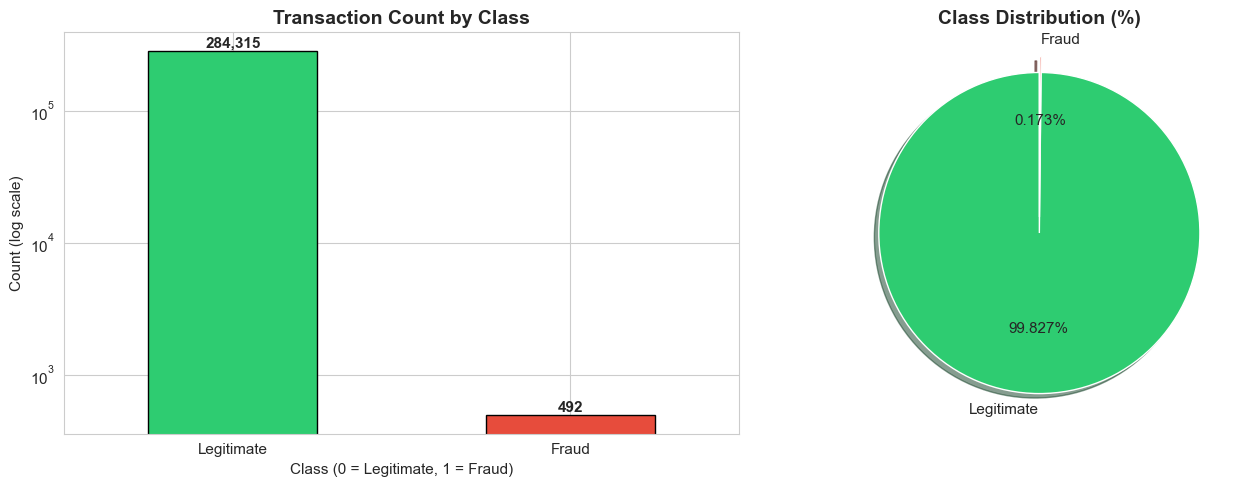


⚠️ INSIGHT: With 0.172% fraud, a dumb model saying 'never fraud' 
   would score 99.83% accuracy but catch 0 frauds. This is why we
   use Precision, Recall, F1, and ROC-AUC — not just accuracy.


In [4]:
# Calculate class distribution
class_counts = df['Class'].value_counts()
class_percent = df['Class'].value_counts(normalize=True) * 100

print("🎯 CLASS DISTRIBUTION")
print("=" * 60)
print(f"Legitimate transactions: {class_counts[0]:,} ({class_percent[0]:.3f}%)")
print(f"Fraudulent transactions: {class_counts[1]:,} ({class_percent[1]:.3f}%)")
print(f"Imbalance ratio: 1 fraud per {class_counts[0] // class_counts[1]} legit transactions")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0 = Legitimate, 1 = Fraud)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_yscale('log')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
for i, v in enumerate(class_counts):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.3f%%',
            colors=colors, startangle=90, explode=(0, 0.1), shadow=True)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️ INSIGHT: With 0.172% fraud, a dumb model saying 'never fraud' ")
print("   would score 99.83% accuracy but catch 0 frauds. This is why we")
print("   use Precision, Recall, F1, and ROC-AUC — not just accuracy.")

💰 TRANSACTION AMOUNT ANALYSIS

Fraudulent transactions:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64

Legitimate transactions:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64


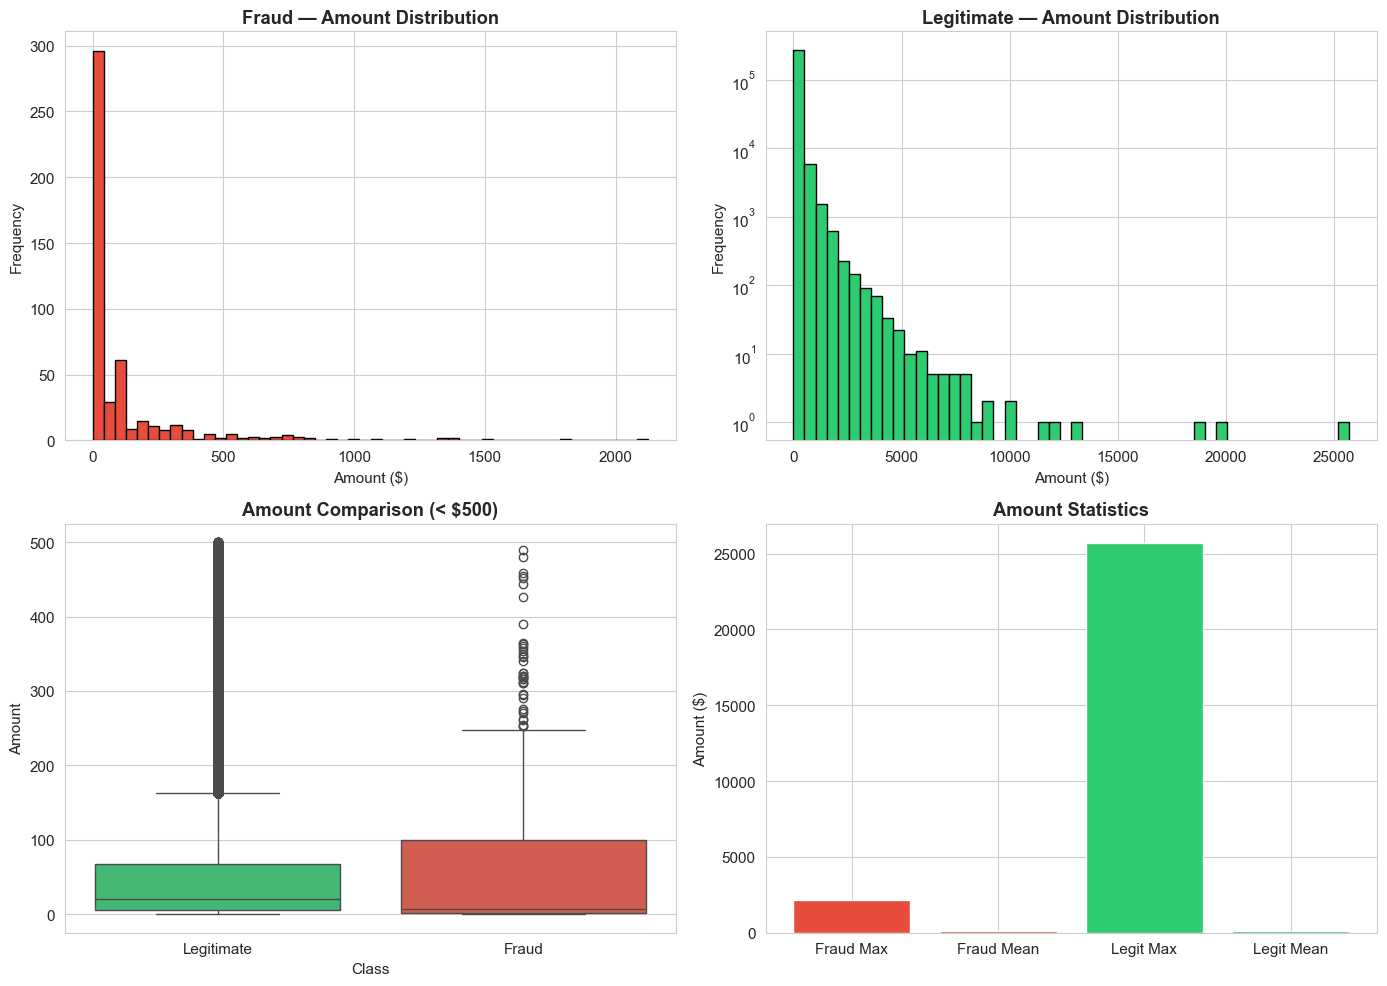


🔍 INSIGHT: Fraud avg = $122.21 vs Legit avg = $88.29
   Fraudsters tend to use SMALLER amounts to avoid detection.


In [5]:
# Split into fraud vs legit
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print("💰 TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)
print("\nFraudulent transactions:")
print(fraud['Amount'].describe().round(2))
print("\nLegitimate transactions:")
print(legit['Amount'].describe().round(2))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram — fraud
axes[0, 0].hist(fraud['Amount'], bins=50, color='#e74c3c', edgecolor='black')
axes[0, 0].set_title('Fraud — Amount Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Frequency')

# Histogram — legit
axes[0, 1].hist(legit['Amount'], bins=50, color='#2ecc71', edgecolor='black')
axes[0, 1].set_title('Legitimate — Amount Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Amount ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_yscale('log')

# Boxplot comparison (limited to $500 for readability)
sns.boxplot(data=df[df['Amount'] < 500], x='Class', y='Amount', ax=axes[1, 0], palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Amount Comparison (< $500)', fontweight='bold')
axes[1, 0].set_xticklabels(['Legitimate', 'Fraud'])

# Top amounts
axes[1, 1].bar(['Fraud Max', 'Fraud Mean', 'Legit Max', 'Legit Mean'],
               [fraud['Amount'].max(), fraud['Amount'].mean(),
                legit['Amount'].max(), legit['Amount'].mean()],
               color=['#e74c3c', '#c0392b', '#2ecc71', '#27ae60'])
axes[1, 1].set_title('Amount Statistics', fontweight='bold')
axes[1, 1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.savefig('../reports/02_amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🔍 INSIGHT: Fraud avg = ${fraud['Amount'].mean():.2f} vs Legit avg = ${legit['Amount'].mean():.2f}")
print(f"   Fraudsters tend to use SMALLER amounts to avoid detection.")

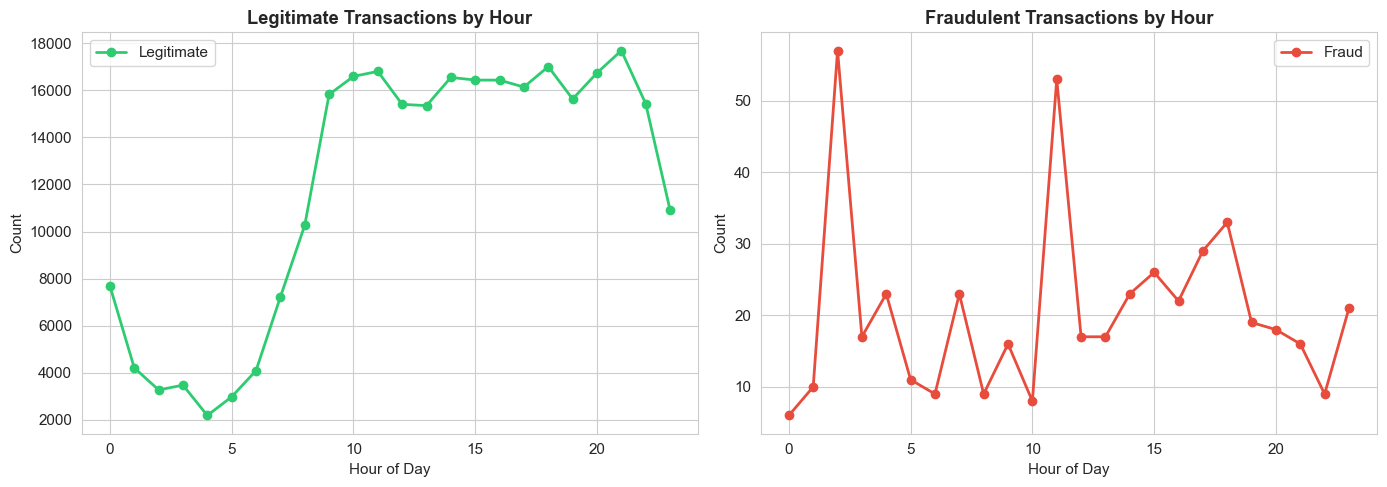

🔍 INSIGHT: Legit transactions follow day/night patterns.
   Fraud is more evenly distributed — fraudsters don't sleep!


In [6]:
# Convert Time (seconds from first transaction) to hours
df['Hour'] = (df['Time'] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transactions by hour
fraud_by_hour = df[df['Class'] == 1]['Hour'].value_counts().sort_index()
legit_by_hour = df[df['Class'] == 0]['Hour'].value_counts().sort_index()

axes[0].plot(legit_by_hour.index, legit_by_hour.values, marker='o', color='#2ecc71', label='Legitimate', linewidth=2)
axes[0].set_title('Legitimate Transactions by Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', color='#e74c3c', label='Fraud', linewidth=2)
axes[1].set_title('Fraudulent Transactions by Hour', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/03_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("🔍 INSIGHT: Legit transactions follow day/night patterns.")
print("   Fraud is more evenly distributed — fraudsters don't sleep!")

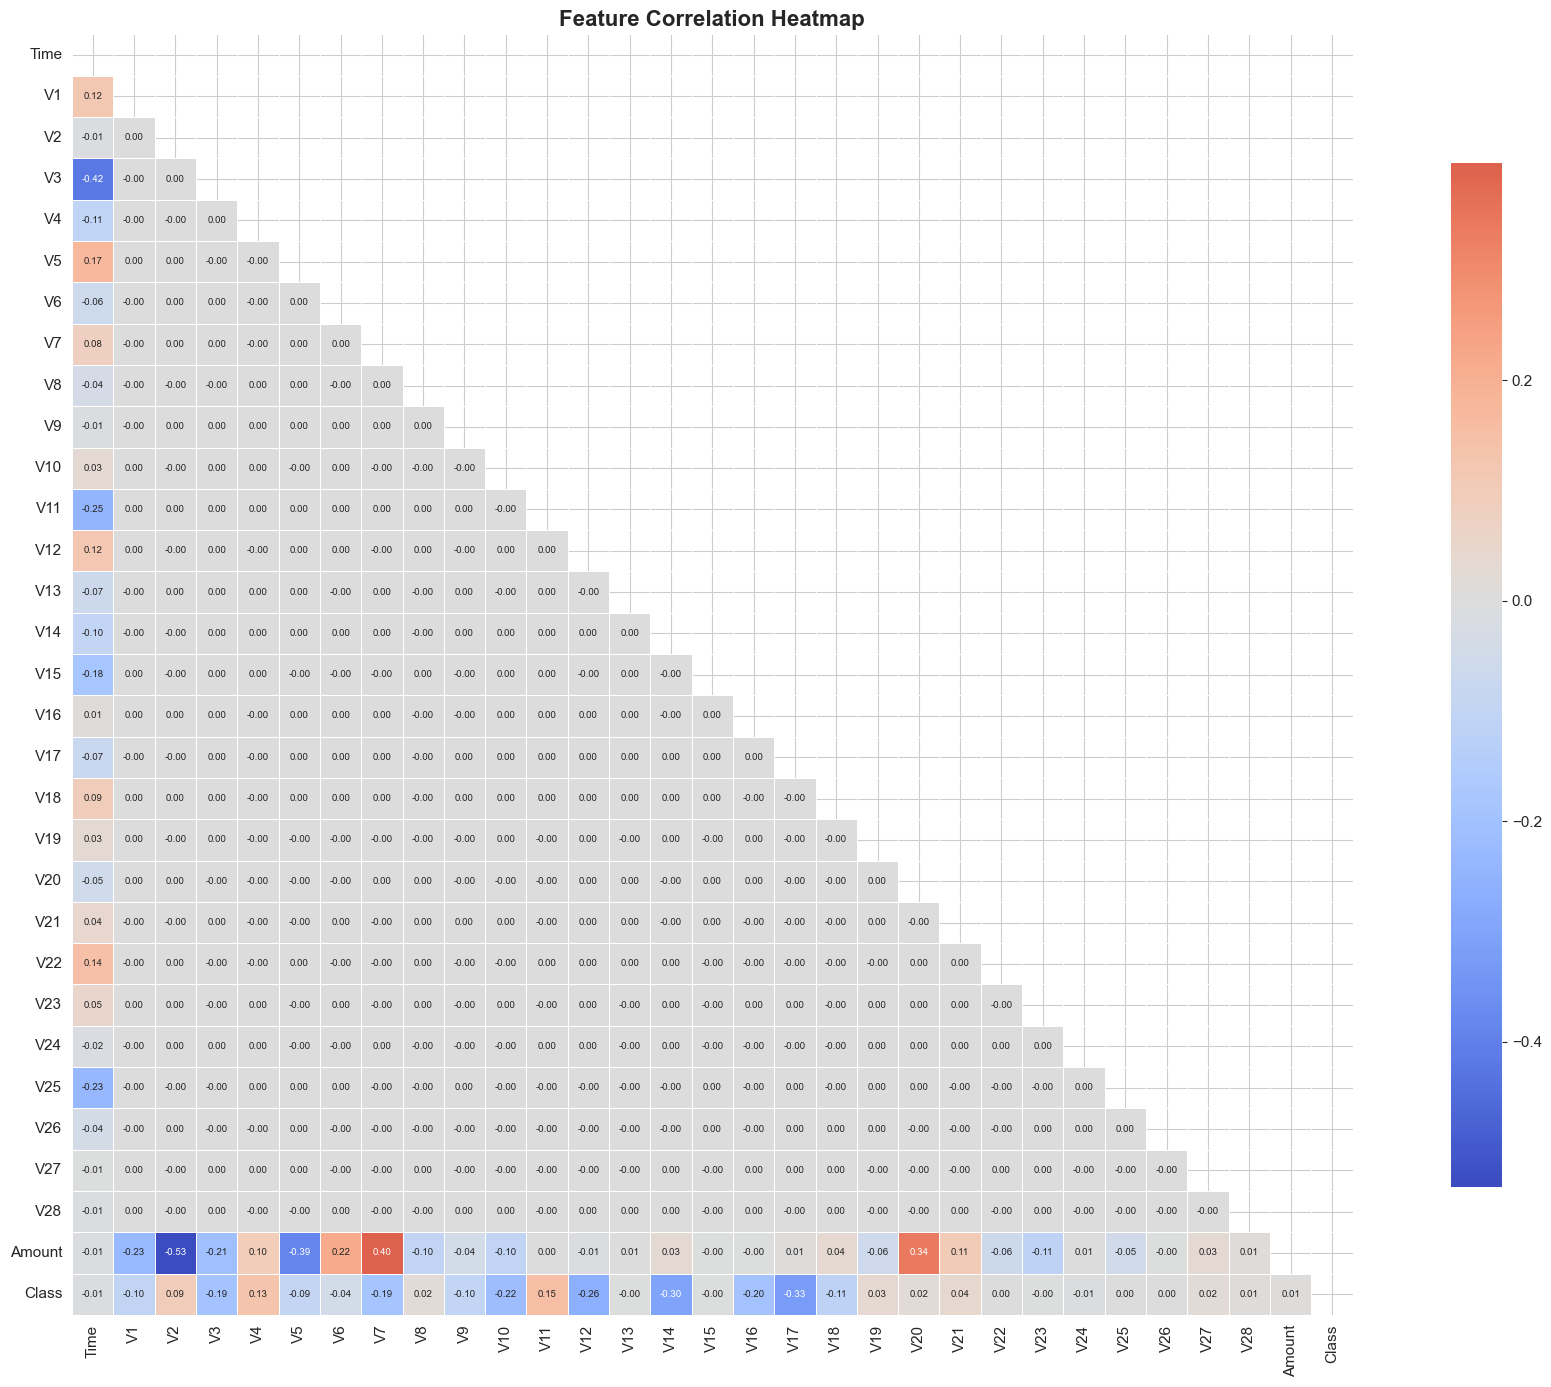


🎯 TOP 10 FEATURES MOST CORRELATED WITH FRAUD
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
V4     0.1334
V18    0.1115
Name: Class, dtype: float64


In [7]:
plt.figure(figsize=(20, 14))
corr = df.drop('Hour', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features correlated with fraud
print("\n🎯 TOP 10 FEATURES MOST CORRELATED WITH FRAUD")
print("=" * 60)
fraud_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False)
print(fraud_corr.head(10).round(4))

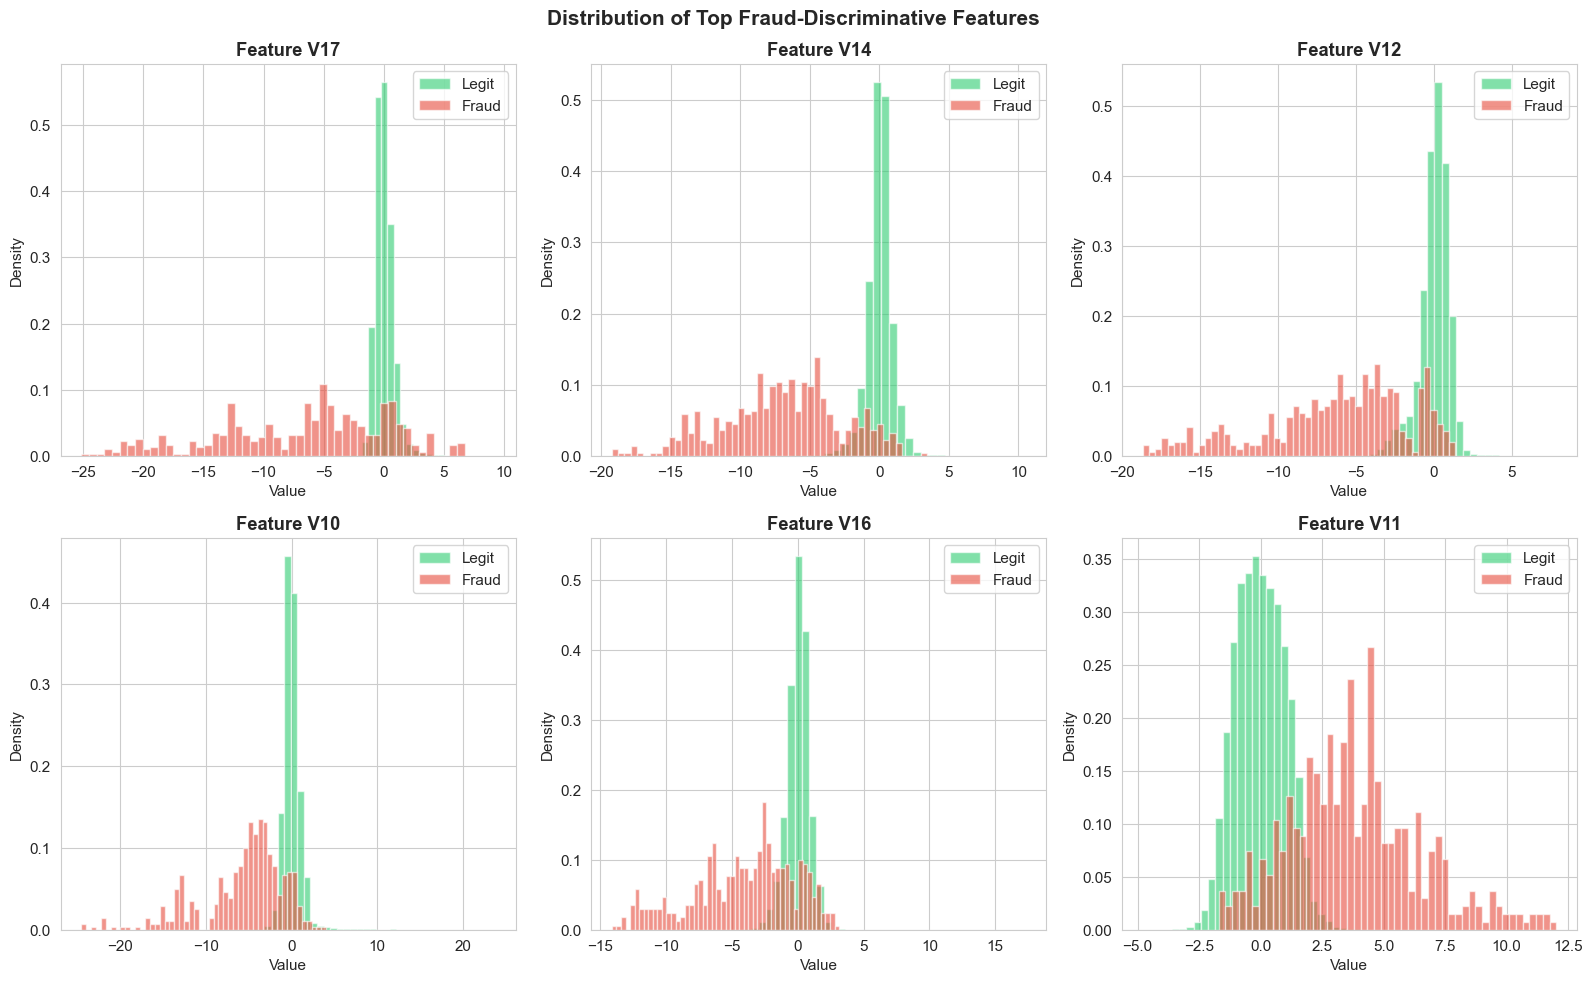

🔍 INSIGHT: Features V17, V14, V12, V10 show CLEAR separation between
   fraud (red) and legitimate (green) distributions. These will be
   the most important signals for our ML models.


In [8]:
# The top features from correlation analysis
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V11']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].hist(legit[feat], bins=50, alpha=0.6, label='Legit', color='#2ecc71', density=True)
    axes[i].hist(fraud[feat], bins=50, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
    axes[i].set_title(f'Feature {feat}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Distribution of Top Fraud-Discriminative Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/05_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("🔍 INSIGHT: Features V17, V14, V12, V10 show CLEAR separation between")
print("   fraud (red) and legitimate (green) distributions. These will be")
print("   the most important signals for our ML models.")

In [9]:
print("=" * 70)
print("📋 EDA SUMMARY — KEY FINDINGS FOR MODELING")
print("=" * 70)
print(f"""
1. DATASET SIZE
   • Total transactions: {len(df):,}
   • Features: {df.shape[1] - 2}
   • Missing values: {df.isnull().sum().sum()}

2. CLASS IMBALANCE (CRITICAL)
   • Legitimate: {class_counts[0]:,} ({class_percent[0]:.3f}%)
   • Fraud:      {class_counts[1]:,} ({class_percent[1]:.3f}%)
   • Ratio:      1 : {class_counts[0] // class_counts[1]}
   ⚠️  MUST use SMOTE or class_weight to handle this

3. AMOUNT PATTERNS
   • Fraud avg: ${fraud['Amount'].mean():.2f}   |   Legit avg: ${legit['Amount'].mean():.2f}
   • Fraudsters prefer smaller amounts

4. TEMPORAL PATTERNS
   • Legit follows day/night cycle
   • Fraud is evenly distributed across hours

5. MOST IMPORTANT FEATURES
   • V17, V14, V12, V10 have highest correlation with fraud
   • Clear visual separation in their distributions

6. METRICS TO USE (NOT accuracy alone!)
   • Precision  — of predicted frauds, how many were real?
   • Recall     — of real frauds, how many did we catch?
   • F1-Score   — balance of precision and recall
   • ROC-AUC    — overall ranking quality

✅ READY FOR PHASE 4: Preprocessing + SMOTE
""")

📋 EDA SUMMARY — KEY FINDINGS FOR MODELING

1. DATASET SIZE
   • Total transactions: 284,807
   • Features: 30
   • Missing values: 0

2. CLASS IMBALANCE (CRITICAL)
   • Legitimate: 284,315 (99.827%)
   • Fraud:      492 (0.173%)
   • Ratio:      1 : 577
   ⚠️  MUST use SMOTE or class_weight to handle this

3. AMOUNT PATTERNS
   • Fraud avg: $122.21   |   Legit avg: $88.29
   • Fraudsters prefer smaller amounts

4. TEMPORAL PATTERNS
   • Legit follows day/night cycle
   • Fraud is evenly distributed across hours

5. MOST IMPORTANT FEATURES
   • V17, V14, V12, V10 have highest correlation with fraud
   • Clear visual separation in their distributions

6. METRICS TO USE (NOT accuracy alone!)
   • Precision  — of predicted frauds, how many were real?
   • Recall     — of real frauds, how many did we catch?
   • F1-Score   — balance of precision and recall
   • ROC-AUC    — overall ranking quality

✅ READY FOR PHASE 4: Preprocessing + SMOTE

